# M4 — Backtesting y Validación walk-forward

**Roboadvisor TFM.** Este notebook valida las tres carteras optimizadas en M3 sobre el periodo OOS 2020-01-02 → 2026-04-30, comparándolas contra SPY y la cartera 60/40 sintética (`0.6·CSPX.L + 0.4·IEAG.AS`). Los pesos se regeneran OOS-clean con μ/Σ ≤ 2019-12-31 para eliminar look-ahead bias.

Criterio Go/No-Go: `Sharpe(moderado) ≥ Sharpe(60_40)`.

## Bloque 0 — Setup

In [1]:
# Bootstrap de paths (igual que M3)
import sys
from pathlib import Path as _P

_repo = _P.cwd().resolve()
while _repo != _repo.parent and not (_repo / "src" / "roboadvisor_paths.py").exists():
    _repo = _repo.parent
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import roboadvisor_paths as PATHS  # noqa: E402
PATHS.ensure_dirs()
M4_OUT = PATHS.OUTPUTS_DIR / "m4"
M4_OUT.mkdir(parents=True, exist_ok=True)

In [2]:
from __future__ import annotations

import json
import logging
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from m3_portfolio import (
    CASH_TICKER,
    EqualWeightOptimizer,
    HRPOptimizer,
    MaxSharpeOptimizer,
    MinVarianceOptimizer,
    RISK_FREE_RATE,
    TRADING_DAYS,
)
from m4_backtesting import (
    BacktestEngine,
    build_60_40_benchmark,
    build_spy_benchmark,
    cagr,
    annual_vol,
    calmar_ratio,
    drawdown_series,
    max_drawdown,
    regenerate_oos_clean_weights,
    sharpe_ratio,
    sortino_ratio,
)

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(name)s %(levelname)s %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("m4_notebook")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## Bloque 1 — Generación de pesos OOS-clean

Truncamos `returns.parquet` a `index ≤ 2019-12-31`, recalculamos μ y Σ (Ledoit-Wolf) sobre la ventana truncada y re-invocamos los optimizadores de M3 con la **misma** configuración (`PROFILES`, `MAX_VOL`, `PRIMARY_OPTIMIZER`, `ALTERNATIVE_OPTIMIZER`, `BASELINE_OPTIMIZER`). Aplicamos la regla de selección de M3 (best Sharpe ex-ante sujeto a `vol_actual ≤ vol_cap × 1.01`).

In [3]:
# Config idéntica a la usada en M3 (notebook m3_optimizacion_carteras.ipynb)
PROFILES: dict[str, list[str]] = {
    "conservador": ["IEAG.AS", "EUNH.DE", "IBCI.AS"],
    "moderado":    ["INFR.AS", "IHYG.L", "EXSA.DE"],
    "agresivo":    ["CSPX.L", "EQQQ.DE", "EXI2.DE"],
}
MAX_VOL: dict[str, float] = {"conservador": 0.08, "moderado": 0.15, "agresivo": 0.25}
PRIMARY_OPTIMIZER:     dict[str, type] = {"conservador": MinVarianceOptimizer, "moderado": MaxSharpeOptimizer, "agresivo": HRPOptimizer}
ALTERNATIVE_OPTIMIZER: dict[str, type] = {"conservador": MaxSharpeOptimizer,   "moderado": HRPOptimizer,      "agresivo": MaxSharpeOptimizer}
BASELINE_OPTIMIZER = EqualWeightOptimizer
TRAIN_END = pd.Timestamp("2019-12-31")
OOS_START = pd.Timestamp("2020-01-02")
OOS_END   = pd.Timestamp("2026-04-30")

In [4]:
returns_full = pd.read_parquet(PATHS.M2_RETURNS_PARQUET)
print(f"returns_full: {returns_full.shape}, {returns_full.index.min().date()} → {returns_full.index.max().date()}")

selected_oos = regenerate_oos_clean_weights(
    returns=returns_full,
    train_end_date=TRAIN_END,
    profiles=PROFILES,
    max_vol=MAX_VOL,
    primary_optimizer=PRIMARY_OPTIMIZER,
    alternative_optimizer=ALTERNATIVE_OPTIMIZER,
    baseline_optimizer=BASELINE_OPTIMIZER,
    risk_free_rate=RISK_FREE_RATE,
    trading_days=TRADING_DAYS,
)
for profile, p in selected_oos.items():
    print(f"[{profile:<11}] {p}")

13:37:50 m4_backtesting.weights_generator INFO Returns truncated: [2010-09-16, 2019-12-31], 2384 days, 9 tickers
13:37:50 m4_backtesting.weights_generator INFO mu/cov estimated on train window (Ledoit-Wolf).
13:37:50 m3_portfolio.min_variance INFO MinVariance optimize [conservador]: n_assets=3, vol_cap=8.00%
13:37:50 m3_portfolio._build INFO Built Portfolio(profile='conservador', optimizer='min_variance', ret=2.73%, vol=3.47%, sharpe=0.210, cash=0.00%, hhi=0.627, n_eff=3)
13:37:50 m3_portfolio.max_sharpe INFO MaxSharpe optimize [conservador]: n_assets=3, vol_cap=8.00%, rf=2.00%
13:37:50 m3_portfolio._build INFO Built Portfolio(profile='conservador', optimizer='max_sharpe', ret=3.12%, vol=4.03%, sharpe=0.278, cash=0.00%, hhi=0.804, n_eff=2)
13:37:50 m3_portfolio.equal_weight INFO EqualWeight optimize [conservador]: n_assets=3, vol_cap=8.00%
13:37:50 m3_portfolio._build INFO Built Portfolio(profile='conservador', optimizer='equal_weight', ret=2.62%, vol=3.74%, sharpe=0.166, cash=0.00%, h

returns_full: (4016, 9), 2010-09-16 → 2026-05-12
[conservador] Portfolio(profile='conservador', optimizer='max_sharpe', ret=3.12%, vol=4.03%, sharpe=0.278, cash=0.00%, hhi=0.804, n_eff=2)
[moderado   ] Portfolio(profile='moderado', optimizer='max_sharpe', ret=5.58%, vol=7.05%, sharpe=0.508, cash=0.00%, hhi=0.456, n_eff=3)
[agresivo   ] Portfolio(profile='agresivo', optimizer='max_sharpe', ret=16.01%, vol=14.18%, sharpe=0.988, cash=0.00%, hhi=0.543, n_eff=2)


In [5]:
# Persistir pesos OOS-clean y summary
weights_rows = []
for profile, p in selected_oos.items():
    for ticker, w in p.weights.items():
        weights_rows.append({"profile": profile, "ticker": ticker, "weight": float(w)})
weights_oos_df = pd.DataFrame(weights_rows).set_index(["profile", "ticker"]).sort_index()
weights_oos_path = M4_OUT / "weights_oos_clean.parquet"
weights_oos_df.to_parquet(weights_oos_path)
print(f"Saved → {weights_oos_path}")

summary_oos = {
    profile: {
        "optimizer": p.optimizer_name,
        "weights": {k: float(v) for k, v in p.weights.items()},
        "cash_weight": float(p.cash_weight),
        "expected_return": float(p.expected_return),
        "expected_volatility": float(p.expected_volatility),
        "expected_sharpe": float(p.expected_sharpe),
        "max_volatility": float(MAX_VOL[profile]),
    }
    for profile, p in selected_oos.items()
}
summary_oos_path = M4_OUT / "portfolios_summary_oos_clean.json"
with open(summary_oos_path, "w", encoding="utf-8") as fh:
    json.dump(summary_oos, fh, indent=2, ensure_ascii=False)
print(f"Saved → {summary_oos_path}")
weights_oos_df

Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\weights_oos_clean.parquet
Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\portfolios_summary_oos_clean.json


weight
profile     ticker           
agresivo    CSPX.L   0.646895
            EQQQ.DE  0.353105
            EXI2.DE  0.000000
conservador EUNH.DE  0.890143
            IBCI.AS  0.000000
            IEAG.AS  0.109857
moderado    EXSA.DE  0.067523
            IHYG.L   0.556560
            INFR.AS  0.375917

## Bloque 2 — Carga de datos OOS

Recortamos `returns_full` a la ventana `[OOS_START, OOS_END]` y dejamos preparados los pesos objetivo (extraídos de las carteras OOS-clean).

In [6]:
returns_oos = returns_full.loc[OOS_START:OOS_END].copy()
print(f"returns_oos: {returns_oos.shape}, {returns_oos.index.min().date()} → {returns_oos.index.max().date()}")

# Pesos objetivo por perfil (incluye CASH si aplica)
target_weights: dict[str, dict[str, float]] = {
    profile: {k: float(v) for k, v in p.weights.items() if v > 0 or k == CASH_TICKER}
    for profile, p in selected_oos.items()
}
for profile, tw in target_weights.items():
    print(profile, tw)

returns_oos: (1624, 9), 2020-01-02 → 2026-04-30
conservador {'IEAG.AS': 0.10985719287079483, 'EUNH.DE': 0.8901428071292052}
moderado {'INFR.AS': 0.3759167365443167, 'IHYG.L': 0.5565601909955745, 'EXSA.DE': 0.0675230724601089}
agresivo {'CSPX.L': 0.6468948727833548, 'EQQQ.DE': 0.3531051272166452}


## Bloque 3 — Configuración del backtest

- Frecuencia de rebalanceo: **trimestral** (`Q`).
- Drift threshold: `None` (solo rebalanceo por calendar, para reproducibilidad simple).
- Risk-free anual: 2% (coherente con M3).

In [7]:
BACKTEST_CONFIG = {
    "rebalance_freq": "Q",
    "drift_threshold": None,
    "rf_annual": RISK_FREE_RATE,
    "trading_days": TRADING_DAYS,
}
BACKTEST_CONFIG

{'rebalance_freq': 'Q',
 'drift_threshold': None,
 'rf_annual': 0.02,
 'trading_days': 252}

## Bloque 4 — Ejecución por perfil

Tres `BacktestEngine`, uno por perfil. Cada uno produce un `BacktestResult` con equity curve base 1.0, retornos diarios, histórico de pesos y log de rebalanceos.

In [8]:
# Reordenamos columnas para que coincidan con el universo de cada perfil
results: dict = {}
for profile in PROFILES:
    universe = [t for t in target_weights[profile] if t != CASH_TICKER]
    engine = BacktestEngine(
        returns=returns_oos[universe],
        target_weights=target_weights[profile],
        **BACKTEST_CONFIG,
    )
    results[profile] = engine.run()
    r = results[profile]
    print(f"[{profile:<11}] equity_final={r.equity_curve.iloc[-1]:.4f}, rebalances={len(r.rebalance_dates)}")

13:37:50 m4_backtesting.engine INFO Backtest done: 1624 days, 26 rebalances, final_equity=0.9014


[conservador] equity_final=0.9014, rebalances=26


13:37:50 m4_backtesting.engine INFO Backtest done: 1624 days, 26 rebalances, final_equity=1.3018
13:37:50 m4_backtesting.engine INFO Backtest done: 1624 days, 26 rebalances, final_equity=2.6306


[moderado   ] equity_final=1.3018, rebalances=26
[agresivo   ] equity_final=2.6306, rebalances=26


## Bloque 5 — Benchmarks

SPY (S&P 500 US, USD) y 60/40 sintético en EUR (`0.6·CSPX.L + 0.4·IEAG.AS` con rebalanceo trimestral).

In [9]:
spy_prices = pd.read_parquet(PATHS.M2_OUTPUTS_DIR / "spy_prices.parquet")
spy_returns = build_spy_benchmark(spy_prices, OOS_START, OOS_END)
spy_equity = (1 + spy_returns).cumprod()
spy_equity = pd.concat([pd.Series([1.0], index=[spy_equity.index[0] - pd.Timedelta(days=1)]), spy_equity])
spy_equity.name = "spy"

bench_60_40_returns = build_60_40_benchmark(returns_oos)
bench_60_40_equity = (1 + bench_60_40_returns).cumprod()
bench_60_40_equity.name = "bench_60_40"

print(f"SPY: {len(spy_returns)} días, equity final={spy_equity.iloc[-1]:.4f}")
print(f"60/40: {len(bench_60_40_returns)} días, equity final={bench_60_40_equity.iloc[-1]:.4f}")

13:37:51 m4_backtesting.benchmarks INFO SPY benchmark built: 1589 days, [2020-01-03, 2026-04-30]
13:37:51 m4_backtesting.engine INFO Backtest done: 1624 days, 26 rebalances, final_equity=1.6668
13:37:51 m4_backtesting.benchmarks INFO 60/40 benchmark built: 1624 days, 26 rebalances


SPY: 1589 días, equity final=2.4206
60/40: 1624 días, equity final=1.6668


In [10]:
# Empaquetar equity curves para persistencia
equity_curves = pd.DataFrame({
    f"equity_{profile}": results[profile].equity_curve
    for profile in PROFILES
})
equity_curves["equity_spy"] = spy_equity.reindex(equity_curves.index).ffill()
equity_curves["equity_60_40"] = bench_60_40_equity.reindex(equity_curves.index).ffill()
equity_curves.to_parquet(M4_OUT / "equity_curves.parquet")
print(f"Saved → {M4_OUT / 'equity_curves.parquet'}")
equity_curves.tail()

Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\equity_curves.parquet


,equity_conservador,equity_moderado,equity_agresivo,equity_spy,equity_60_40
Date,,,,,
2026-04-24,0.902338,1.295865,2.623639,2.404743,1.663605
2026-04-27,0.900881,1.296199,2.625495,2.408886,1.664217
2026-04-28,0.899268,1.298154,2.607886,2.397165,1.658092
2026-04-29,0.897544,1.293924,2.621620,2.396794,1.658984
2026-04-30,0.901416,1.301833,2.630602,2.420641,1.666798


In [11]:
# Log de rebalanceos
rebalance_rows = []
for profile, r in results.items():
    for d in r.rebalance_dates:
        rebalance_rows.append({"profile": profile, "date": d})
rebalance_log_df = pd.DataFrame(rebalance_rows)
rebalance_log_df.to_parquet(M4_OUT / "rebalance_log.parquet")
print(f"Saved → {M4_OUT / 'rebalance_log.parquet'} ({len(rebalance_log_df)} entradas)")

Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\rebalance_log.parquet (78 entradas)


## Bloque 6 — Métricas comparativas

CAGR, vol anualizada, Sharpe, Sortino, Max Drawdown y Calmar para los tres perfiles y los dos benchmarks. Implementación propia (`m4_backtesting.metrics`), no QuantStats.

In [12]:
def _metrics_for(equity: pd.Series, rets: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    mdd, peak, trough = max_drawdown(equity)
    return {
        "CAGR_%": cagr(equity) * 100,
        "vol_%": annual_vol(rets) * 100,
        "Sharpe": sharpe_ratio(rets, rf_annual=rf),
        "Sortino": sortino_ratio(rets, rf_annual=rf),
        "MDD_%": mdd * 100,
        "Calmar": calmar_ratio(equity),
    }

metrics_rows = []
for profile in PROFILES:
    m = _metrics_for(results[profile].equity_curve, results[profile].returns)
    m["serie"] = profile
    metrics_rows.append(m)
metrics_rows.append({"serie": "SPY", **_metrics_for(spy_equity, spy_returns)})
metrics_rows.append({"serie": "60/40", **_metrics_for(bench_60_40_equity, bench_60_40_returns)})
metrics_df = pd.DataFrame(metrics_rows).set_index("serie")
metrics_df = metrics_df[["CAGR_%", "vol_%", "Sharpe", "Sortino", "MDD_%", "Calmar"]]
metrics_df.round(3)

,CAGR_%,vol_%,Sharpe,Sortino,MDD_%,Calmar
serie,,,,,,
conservador,-1.599,6.169,-0.554,-0.549,-22.200,-0.072
moderado,4.181,10.065,0.259,0.232,-28.200,0.148
agresivo,16.204,18.499,0.796,0.731,-31.777,0.510
SPY,15.050,20.456,0.690,0.654,-33.717,0.446
60/40,8.256,11.307,0.581,0.547,-22.262,0.371


In [13]:
# Persistir métricas y drawdown series
metrics_dict = {idx: {k: float(v) for k, v in row.items()} for idx, row in metrics_df.iterrows()}
with open(M4_OUT / "metrics_by_profile.json", "w", encoding="utf-8") as fh:
    json.dump(metrics_dict, fh, indent=2, ensure_ascii=False)

dd_df = pd.DataFrame({
    f"dd_{profile}": drawdown_series(results[profile].equity_curve) for profile in PROFILES
})
dd_df["dd_spy"] = drawdown_series(spy_equity).reindex(dd_df.index).ffill()
dd_df["dd_60_40"] = drawdown_series(bench_60_40_equity).reindex(dd_df.index).ffill()
dd_df.to_parquet(M4_OUT / "drawdown_series.parquet")
print(f"Saved → {M4_OUT / 'metrics_by_profile.json'}")
print(f"Saved → {M4_OUT / 'drawdown_series.parquet'}")

Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\metrics_by_profile.json
Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\drawdown_series.parquet


## Bloque 7 — Visualizaciones

Equity curves superpuestas (escala log), drawdown plot y distribución de retornos.

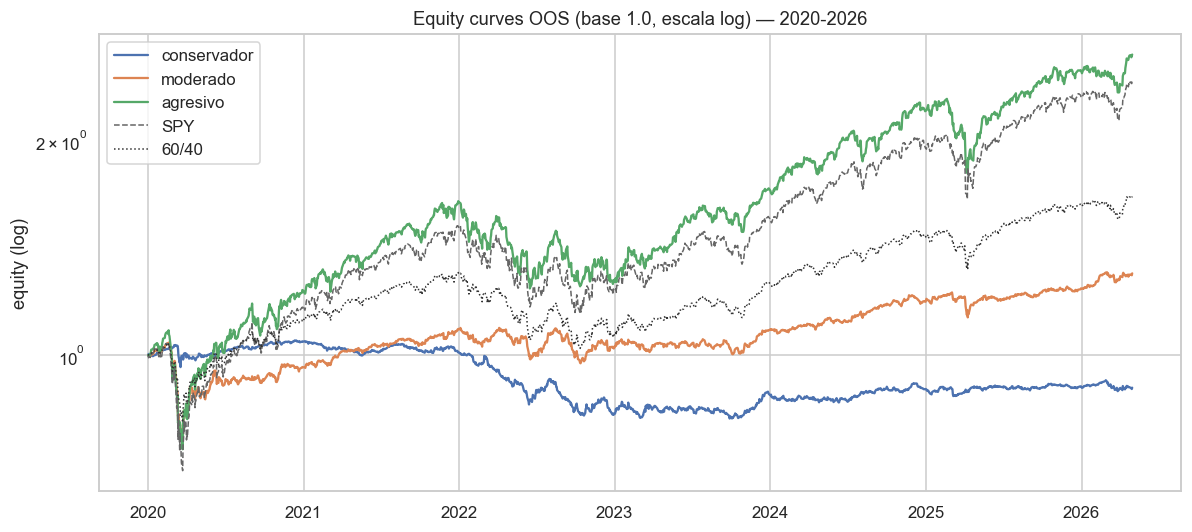

In [14]:
fig, ax = plt.subplots(figsize=(11, 5))
for profile in PROFILES:
    ax.plot(results[profile].equity_curve, label=f"{profile}", linewidth=1.5)
ax.plot(spy_equity, label="SPY", linewidth=1.0, linestyle="--", color="#666666")
ax.plot(bench_60_40_equity, label="60/40", linewidth=1.0, linestyle=":", color="#333333")
ax.set_yscale("log")
ax.set_title("Equity curves OOS (base 1.0, escala log) — 2020-2026")
ax.set_ylabel("equity (log)")
ax.legend()
fig.tight_layout()
plt.show()

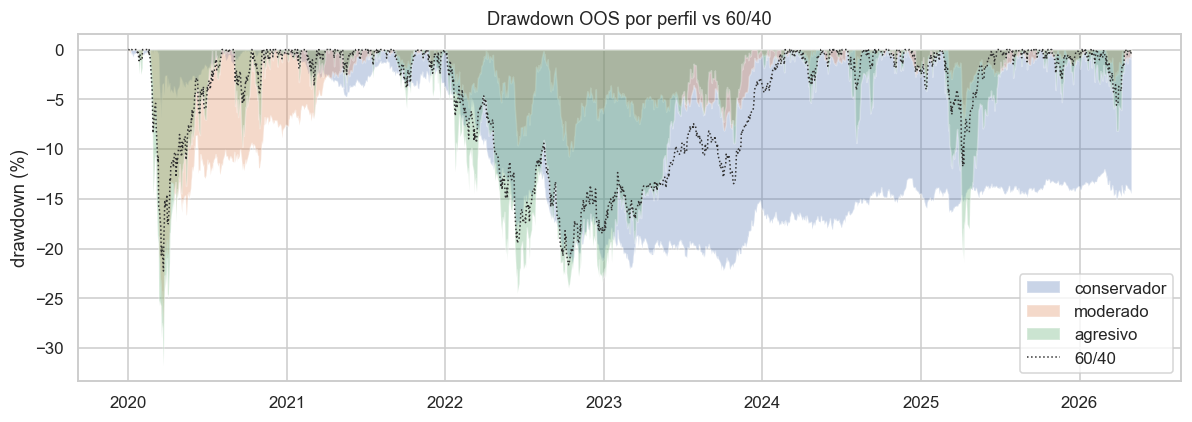

In [15]:
fig, ax = plt.subplots(figsize=(11, 4))
for profile in PROFILES:
    ax.fill_between(dd_df.index, dd_df[f"dd_{profile}"] * 100, 0, alpha=0.3, label=profile)
ax.plot(dd_df.index, dd_df["dd_60_40"] * 100, color="#333333", linewidth=1.0, linestyle=":", label="60/40")
ax.set_title("Drawdown OOS por perfil vs 60/40")
ax.set_ylabel("drawdown (%)")
ax.legend()
fig.tight_layout()
plt.show()

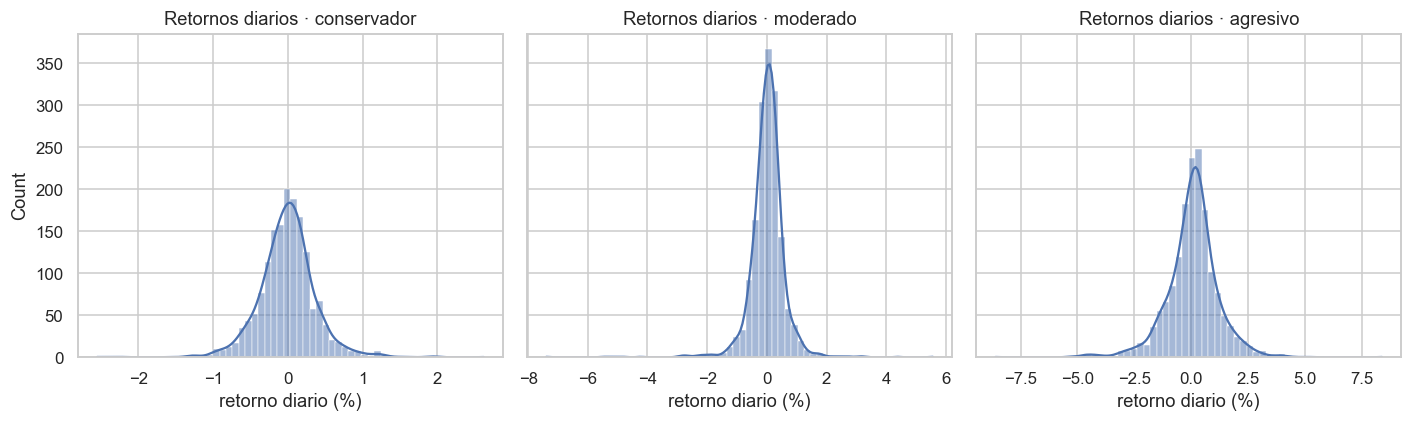

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, profile in zip(axes, PROFILES):
    sns.histplot(results[profile].returns * 100, bins=60, ax=ax, kde=True)
    ax.set_title(f"Retornos diarios · {profile}")
    ax.set_xlabel("retorno diario (%)")
fig.tight_layout()
plt.show()

## Bloque 8 — Tearsheets QuantStats

QuantStats genera el HTML descriptivo. Las métricas canónicas son las del bloque 6 (implementación propia), no las de QuantStats. Esto evita dependencias de versión.

In [17]:
try:
    import quantstats as qs
    qs.extend_pandas()
    for profile in PROFILES:
        rets = results[profile].returns.copy()
        rets.index = pd.to_datetime(rets.index)
        bench = bench_60_40_returns.reindex(rets.index).fillna(0.0)
        out = M4_OUT / f"report_{profile}.html"
        qs.reports.html(rets, benchmark=bench, output=str(out), title=f"M4 · {profile} vs 60/40")
        print(f"Saved → {out}")
except Exception as exc:
    print(f"[WARN] No se pudo generar tearsheet QuantStats: {exc}")

Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\report_conservador.html
Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\report_moderado.html
Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\report_agresivo.html


## Bloque 9 — Comparativa pesos full vs OOS-clean

Side-by-side de los pesos de M3 (`outputs/m3/weights.parquet`, μ/Σ full history) frente a los OOS-clean (μ/Σ ≤ 2019-12-31). Útil para narrativa de la memoria.

In [18]:
weights_m3 = pd.read_parquet(PATHS.M3_WEIGHTS_PARQUET).rename(columns={"weight": "weight_full"})
weights_oos_renamed = weights_oos_df.rename(columns={"weight": "weight_oos"})
comparison = weights_oos_renamed.join(weights_m3, how="outer").fillna(0.0)
comparison["delta"] = comparison["weight_oos"] - comparison["weight_full"]
comparison_path = M4_OUT / "weights_comparison.parquet"
comparison.to_parquet(comparison_path)
print(f"Saved → {comparison_path}")
comparison.round(4)

Saved → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\outputs\m4\weights_comparison.parquet


weight_oos  weight_full   delta
profile     ticker                                  
agresivo    CSPX.L       0.6469       0.5067  0.1402
            EQQQ.DE      0.3531       0.4933 -0.1402
            EXI2.DE      0.0000       0.0000  0.0000
conservador EUNH.DE      0.8901       0.3333  0.5568
            IBCI.AS      0.0000       0.3333 -0.3333
            IEAG.AS      0.1099       0.3333 -0.2235
moderado    EXSA.DE      0.0675       0.6280 -0.5605
            IHYG.L       0.5566       0.0000  0.5566
            INFR.AS      0.3759       0.3720  0.0040

## Bloque 10 — Validación final (Go/No-Go)

In [19]:
sharpe_moderado = metrics_df.loc["moderado", "Sharpe"]
sharpe_60_40    = metrics_df.loc["60/40", "Sharpe"]
cagr_cons = metrics_df.loc["conservador", "CAGR_%"]
cagr_mod  = metrics_df.loc["moderado", "CAGR_%"]
cagr_agr  = metrics_df.loc["agresivo", "CAGR_%"]
vol_cons  = metrics_df.loc["conservador", "vol_%"]
vol_mod   = metrics_df.loc["moderado", "vol_%"]
vol_agr   = metrics_df.loc["agresivo", "vol_%"]

checks = {
    "GO/NOGO · Sharpe(moderado) >= Sharpe(60/40)": sharpe_moderado >= sharpe_60_40,
    "Ordenación CAGR · agresivo > moderado > conservador": cagr_agr > cagr_mod > cagr_cons,
    "Vol conservador <= 8%": vol_cons <= 8.0,
    "Vol moderado <= 15%":   vol_mod  <= 15.0,
    "Vol agresivo <= 25%":   vol_agr  <= 25.0,
}
for desc, ok in checks.items():
    tag = "PASS" if ok else "FAIL"
    print(f"  [{tag}] {desc}")

print()
print(f"Sharpe moderado: {sharpe_moderado:.4f}  |  Sharpe 60/40: {sharpe_60_40:.4f}")
print(f"CAGR  cons / mod / agr: {cagr_cons:.2f}% / {cagr_mod:.2f}% / {cagr_agr:.2f}%")
print(f"Vol   cons / mod / agr: {vol_cons:.2f}% / {vol_mod:.2f}% / {vol_agr:.2f}%")

  [FAIL] GO/NOGO · Sharpe(moderado) >= Sharpe(60/40)
  [PASS] Ordenación CAGR · agresivo > moderado > conservador
  [PASS] Vol conservador <= 8%
  [PASS] Vol moderado <= 15%
  [PASS] Vol agresivo <= 25%

Sharpe moderado: 0.2587  |  Sharpe 60/40: 0.5810
CAGR  cons / mod / agr: -1.60% / 4.18% / 16.20%
Vol   cons / mod / agr: 6.17% / 10.06% / 18.50%
